In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

c:\Users\Sultan Selin\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
DATA_PATH = (
    Path.cwd().parent
    / "data"
    / "raw"
    / "consumption_2017_2026.parquet"
)

df = pd.read_parquet(DATA_PATH)

In [5]:
df.head()

,date,time,consumption
0,2017-01-01T00:00:00+03:00,00:00,27223.06
1,2017-01-01T01:00:00+03:00,01:00,25825.90
2,2017-01-01T02:00:00+03:00,02:00,24252.68
3,2017-01-01T03:00:00+03:00,03:00,22915.47
4,2017-01-01T04:00:00+03:00,04:00,22356.99


In [6]:
df.dtypes


date               str
time               str
consumption    float64
dtype: object

In [5]:
df["date"] = pd.to_datetime(df["date"])

In [8]:
df["date"].dtype

datetime64[us, UTC+03:00]

In [6]:
df = df.drop(columns=["time"])

In [10]:
#duplication exists?
duplicate_count = df["date"].duplicated().sum()
if duplicate_count == 0:
    print("No duplicate exists")
else: 
    print("Duplicates exists")
    

No duplicate exists


In [11]:
df.isna().sum()

date           0
consumption    0
dtype: int64

In [12]:
df["date"].diff().value_counts()

date
0 days 01:00:00    84695
Name: count, dtype: int64

In [14]:
df["date"].is_monotonic_decreasing

False

In [18]:
print(df.describe())
df["consumption"].max()

max_index = df["consumption"].idxmax()
min_index = df["consumption"].idxmin()

print("Max consumption", df.loc[max_index, ["date", "consumption"]])
print("Min consumption", df.loc[min_index, ["date", "consumption"]])

        consumption
count  84696.000000
mean   36295.307239
std     6408.310997
min    15333.300000
25%    31565.447500
50%    35939.680000
75%    40532.420000
max    59503.670000
Max consumption date           2025-07-28 14:00:00+03:00
consumption                     59503.67
Name: 75134, dtype: object
Min consumption date           2020-05-25 07:00:00+03:00
consumption                      15333.3
Name: 29767, dtype: object


Text(0.5, 1.0, 'Histogram of Consumption')

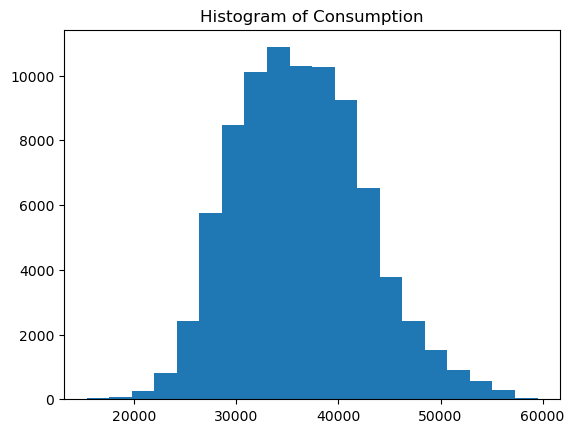

In [8]:
plt.hist(df["consumption"], bins = 20)
plt.title("Histogram of Consumption")

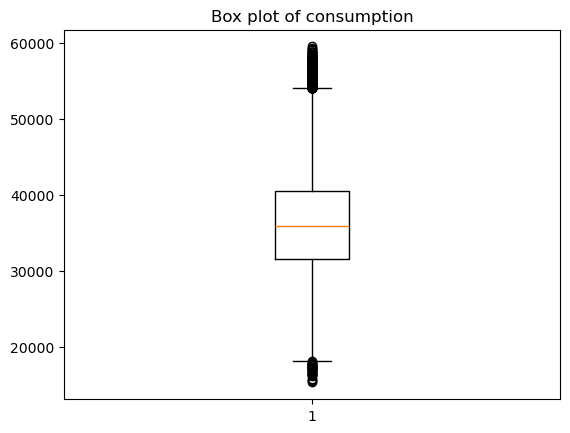

In [10]:
plt.boxplot(df["consumption"])
plt.title("Box plot of consumption")
plt.show()

In [19]:
### checking outliers
q1 = df["consumption"].quantile(0.25)
q3 = df["consumption"].quantile(0.75)

iqr = q3 - q1
lb = q1 - 1.5 * iqr
ub = q3 + 1.5 * iqr

lower_mask = df["consumption"] < lb  
upper_mask =df["consumption"] > ub
lower_count = lower_mask.sum()
upper_count = upper_mask.sum()
print("Lower outliers:",lower_count)
print("Upper outliers:", upper_count)

#yearly
outliers_l = df[lower_mask].copy()
print("lower bound", outliers_l["date"].dt.year.value_counts().sort_index())
outliers_u = df[upper_mask].copy()
print("upper bound", outliers_u["date"].dt.year.value_counts().sort_index())

#monthly
print("lower bound", outliers_l["date"].dt.month.value_counts().sort_index())
print("upper bound", outliers_u["date"].dt.month.value_counts().sort_index())

Lower outliers: 36
Upper outliers: 558
lower bound date
2020    36
Name: count, dtype: int64
upper bound date
2021     12
2023      1
2024    123
2025    190
2026    232
Name: count, dtype: int64
lower bound date
4     3
5    33
Name: count, dtype: int64
upper bound date
6      2
7    240
8    316
Name: count, dtype: int64


In [22]:
PROCESSED_PATH = (
    Path.cwd().parent
    / "data"
    / "processed"
    / "consumption_validated.parquet"
)
df.to_parquet(PROCESSED_PATH, index=False)